# Log Anomaly Detection (BGL Dataset): Isolation Forest Pipeline


In [1]:
# =============================================================================
# CELL 1 — PACKAGE INSTALLATION
# =============================================================================

import subprocess, sys

def install_packages(packages):
    for pkg in packages:
        print(f"Installing: {pkg}")
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", pkg, "-q"],
            capture_output=True, text=True,
        )
        if result.returncode != 0:
            print(f"  WARNING: may have failed — {result.stderr[:200]}")
        else:
            print("  OK")

install_packages([
    "pandas", "numpy", "scikit-learn",
    "matplotlib", "seaborn",
    "sentence-transformers",
])
print("\nAll packages ready.")


Installing: pandas
  OK
Installing: numpy
  OK
Installing: scikit-learn
  OK
Installing: matplotlib
  OK
Installing: seaborn
  OK
Installing: sentence-transformers
  OK

All packages ready.


  Dataset              : BGL
  Embedding model      : all-MiniLM-L6-v2
  IF n_estimators      : 400
  IF max_samples       : 0.9
  IF max_features      : 0.7
  IF contamination     : 0.05
  Val ratio            : 0.25  (of pool)
  Test normals         : 200  (fixed slice — aligned with E01 SVDD)
  Test anomalies       : 15  (fixed slice — aligned with E01 SVDD)
  F-beta               : 0.4
Loading dataset: BGL
  Loading BGL structured log ...
    Rows: 2000, Templates: 120

  Total samples     : 2000
  Normal            : 1857  (92.8%)
  Anomalous         : 143  (7.1%)

  Sample log_text:
    [KERNEL] [INFO] instruction cache parity error corrected | Template: instruction cache parity error corrected
Creating train / validation / test splits ...

  Train  :   1239  normal only
  Val    :    413  normal only  (threshold calibration)
  Test   :    215  total
              200  normal     (93.0%)
               15  anomalous  (7.0%)
Loading sentence transformer 'all-MiniLM-L6-v2' ...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4415.69it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Embedding dimension : 384

Encoding train set (1239 samples) ...


Batches: 100%|██████████| 20/20 [00:08<00:00,  2.31it/s]


Encoding validation set (413 samples) ...


Batches: 100%|██████████| 7/7 [00:02<00:00,  2.59it/s]


Encoding test set (215 samples) ...


Batches: 100%|██████████| 4/4 [00:02<00:00,  1.59it/s]



  Train embeddings  : (1239, 384)
  Val embeddings    : (413, 384)
  Test embeddings   : (215, 384)
Isolation Forest configuration:
  n_estimators  : 400
  max_samples   : 0.9
  max_features  : 0.7
  contamination : 0.05
  random_state  : 42
  n_jobs        : -1  (all cores)

Fitting Isolation Forest on 1239 normal-only embeddings ...
  Training complete.
  Effective max_samples per tree : 1115
  Total trees grown              : 400
Computing validation-set anomaly scores ...
  Val anomaly score stats (normal logs only):
    Min    : -0.1856
    Median : -0.1377
    Max    : 0.0187

  Threshold selection via F-beta (beta=0.4) on validation PR curve:
    Best threshold       : -0.0339
    At threshold         : Precision=1.000  Recall=1.000  F0.4=1.000
    Pseudo-anomaly count : 42  (top 10% of 413 val normals)
Scoring test set ...

  EVALUATION  --  Isolation Forest  [BGL]
  Test set size          : 215
    Normal   (neg)       : 200  (93.0%)
    Anomalous (pos)      : 15  (7.0%)
----

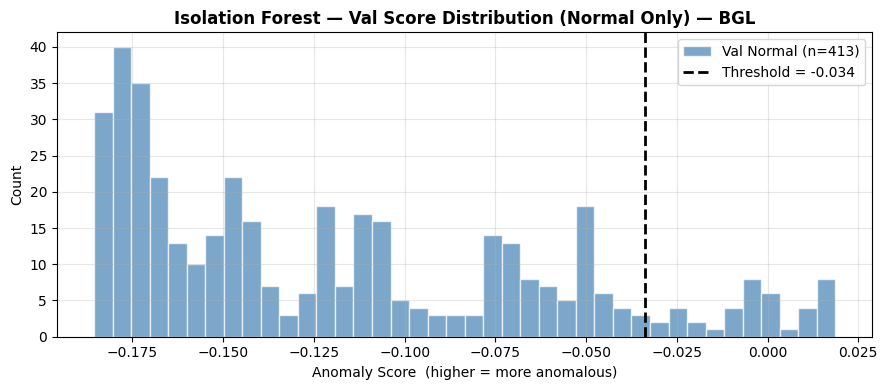

  Saved: bgl_if_val_score_dist.png


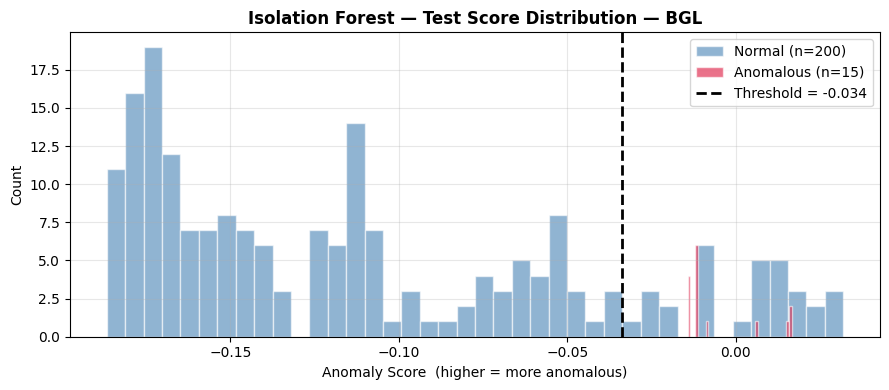

  Saved: bgl_if_test_score_dist.png


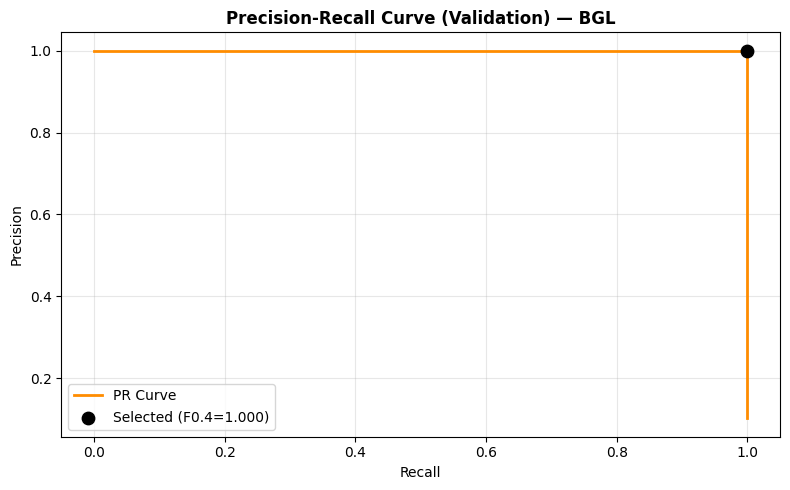

  Saved: bgl_if_pr_curve.png


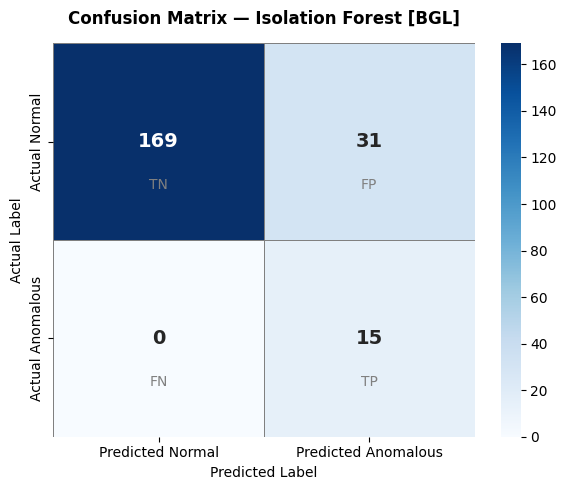

  Saved: bgl_if_confusion_matrix.png


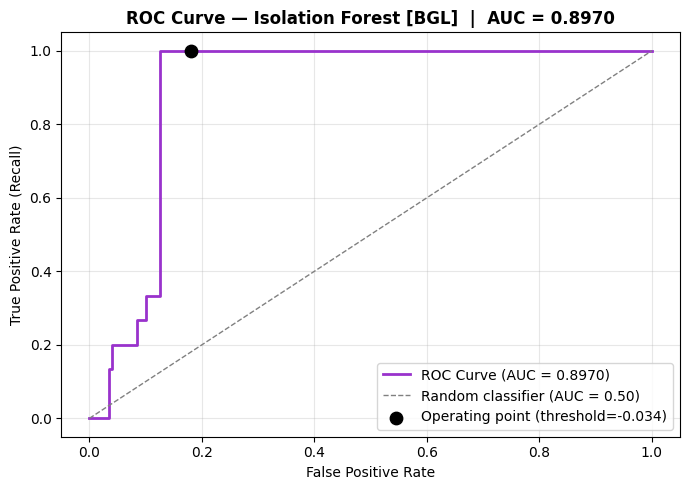

  Saved: bgl_if_roc_curve.png


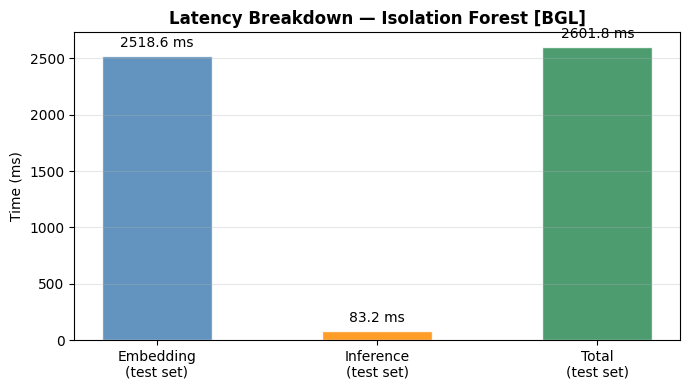

  Saved: bgl_if_latency_summary.png


In [2]:
# =============================================================================
# CELL 2 — IMPORTS AND CONFIGURATION
# =============================================================================

import re
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve,
)

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Dataset selection ─────────────────────────────────────────────────────────
DATASET = "BGL"

# ── Dataset-specific configurations ──────────────────────────────────────────

DATASET_CONFIGS = {
    "BGL": {
        "structured_log_path": "../../Datasets/BGL/Processed/BGL_2k.log_structured.csv",
        "templates_path":      "../../Datasets/BGL/Processed/BGL_2k.log_templates.csv",
        # Schema
        "label_col":     "Label",
        "normal_value":  "-",           # '-' = Normal in BGL
        "event_id_col":  "EventId",
        "component_col": "Component",
        "level_col":     "Level",
        "content_col":   "Content",
        "template_col":  "EventTemplate",
    },
    "HDFS": {
        "traces_path":    "../../Datasets/HDFS/Full_HDFS_v1/preprocessed/Event_traces.csv",
        "templates_path": "../../Datasets/HDFS/Full_HDFS_v1/preprocessed/HDFS.log_templates.csv",
        # Schema
        "label_col":    "Label",
        "normal_value": "Success",      # 'Success' = Normal, 'Fail' = Anomalous
        "features_col": "Features",     # column holding [E5,E22,...] sequence
    },
}

# ── Embedding model ───────────────────────────────────────────────────────────
EMBED_MODEL_NAME = "all-MiniLM-L6-v2"
EMBED_DIM        = 384   # confirmed after model load

# ── Isolation Forest hyper-parameters ────────────────────────────────────────
IF_N_ESTIMATORS  = 400   # number of isolation trees
IF_MAX_SAMPLES   = 0.9  # sub-sample size per tree ("auto" = min(256, n_train))
IF_MAX_FEATURES  = 0.7   # fraction of features per tree split
IF_CONTAMINATION = 0.05  # set to "auto" so no prior anomaly rate assumed at fit time

# ── Split configuration (aligned with E01 SVDD and E04) ───────────────────
N_FEW_SHOT_NORMAL = 5    # test slice start offset — aligned with E04
N_FEW_SHOT_ANOM   = 5    # anomaly slice start offset — aligned with E04
VAL_RATIO        = 0.25  # fraction of model pool for threshold calibration
TEST_NORMAL_CAP  = 200   # test set normal count — aligned with E01 SVDD and E04
TEST_ANOMALY_CAP = 15    # test set anomaly count — aligned with E01 SVDD and E04

# ── Threshold calibration ─────────────────────────────────────────────────────
PSEUDO_ANOMALY_PERCENTILE = 90   # top 10% of val scores = pseudo-anomalies
FBETA = 0.4                      # beta < 1 weights precision over recall

print(f"  Dataset              : {DATASET}")
print(f"  Embedding model      : {EMBED_MODEL_NAME}")
print(f"  IF n_estimators      : {IF_N_ESTIMATORS}")
print(f"  IF max_samples       : {IF_MAX_SAMPLES}")
print(f"  IF max_features      : {IF_MAX_FEATURES}")
print(f"  IF contamination     : {IF_CONTAMINATION}")
print(f"  Val ratio            : {VAL_RATIO}  (of pool)")
print(f"  Test normals         : {TEST_NORMAL_CAP}  (fixed slice — aligned with E01 SVDD)")
print(f"  Test anomalies       : {TEST_ANOMALY_CAP}  (fixed slice — aligned with E01 SVDD)")
print(f"  F-beta               : {FBETA}")


# =============================================================================
# GENERIC DATA LOADING
#
# Output contract (identical for every dataset):
#   log_text     (str)  — enriched text fed to the sentence transformer
#   is_normal    (bool) — True if the sample is labelled Normal
#   binary_label (int)  — 0 = Normal, 1 = Anomalous
#
# BGL  loader : line-level;  one row = one log line
# HDFS loader : block-level; one row = one block trace (event sequence)
# =============================================================================


# ── BGL helpers ───────────────────────────────────────────────────────────────

def build_bgl_log_text(row, config):
    """Construct enriched text for a single BGL log line.

    Format: [COMPONENT] [LEVEL] <content> | Template: <drain_template>
    Combining concrete content with the abstract template improves
    embedding quality by exposing both signal types to the model.
    """
    component = str(row.get(config["component_col"], "")).strip()
    level     = str(row.get(config["level_col"],     "")).strip()
    content   = str(row.get(config["content_col"],   "")).strip()
    template  = str(row.get(config["template_col"],  "")).strip()
    return f"[{component}] [{level}] {content} | Template: {template}"


def load_bgl_data(config):
    """Load BGL structured log CSV, merge templates, build log_text."""
    print("  Loading BGL structured log ...")
    df_logs      = pd.read_csv(config["structured_log_path"])
    df_templates = pd.read_csv(config["templates_path"])
    print(f"    Rows: {len(df_logs)}, Templates: {len(df_templates)}")

    df = df_logs.merge(
        df_templates, on=config["event_id_col"],
        how="left", suffixes=("", "_tmpl"),
    )
    df["is_normal"]    = df[config["label_col"]] == config["normal_value"]
    df["binary_label"] = (~df["is_normal"]).astype(int)
    df["log_text"]     = df.apply(
        lambda row: build_bgl_log_text(row, config), axis=1
    )
    return df


# ── HDFS helpers ──────────────────────────────────────────────────────────────

def _clean_template(text):
    """Remove Drain wildcards [*] and collapse whitespace."""
    cleaned = re.sub(r'\[\*\]', '', text)
    return re.sub(r'\s+', ' ', cleaned).strip()


def build_hdfs_log_text(row, config, template_lookup):
    """Construct enriched text for an HDFS block trace.

    Parses the ordered event-ID sequence from the Features column (e.g.
    [E5,E22,E5,E11,...]), resolves each unique event ID to its Drain
    template, and joins them with ' -> ' to represent the block lifecycle.

    Unique-ordered de-duplication avoids repeating the same template many
    times while preserving the event-ordering signal. Normal blocks produce
    pipeline sentences; anomalous blocks introduce error-event templates
    that give the sentence transformer a distinctive anomaly signal.
    """
    features_str = str(row.get(config["features_col"], "[]"))
    event_ids    = re.findall(r'E\d+', features_str)
    seen, unique_templates = set(), []
    for eid in event_ids:
        if eid not in seen:
            seen.add(eid)
            tmpl = template_lookup.get(eid, eid)
            unique_templates.append(_clean_template(tmpl))
    return "HDFS Block Trace | " + " -> ".join(unique_templates)


def load_hdfs_data(config):
    """Load HDFS Event_traces.csv, build block-level log_text."""
    print("  Loading HDFS block traces ...")
    df_traces    = pd.read_csv(config["traces_path"])
    df_templates = pd.read_csv(config["templates_path"])
    print(f"    Block traces: {len(df_traces)}, Templates: {len(df_templates)}")

    template_lookup = dict(
        zip(df_templates["EventId"], df_templates["EventTemplate"])
    )
    df_traces["is_normal"]    = (
        df_traces[config["label_col"]] == config["normal_value"]
    )
    df_traces["binary_label"] = (~df_traces["is_normal"]).astype(int)
    df_traces["log_text"]     = df_traces.apply(
        lambda row: build_hdfs_log_text(row, config, template_lookup), axis=1
    )
    return df_traces


# ── Public entry point ────────────────────────────────────────────────────────

def load_data(dataset_name, configs):
    """Dispatch to the dataset-specific loader.

    Returns a DataFrame guaranteed to have:
        log_text (str), is_normal (bool), binary_label (int).

    Args:
        dataset_name : "BGL" or "HDFS"
        configs      : DATASET_CONFIGS dict
    """
    if dataset_name not in configs:
        raise ValueError(
            f"Unknown dataset '{dataset_name}'. "
            f"Available: {list(configs.keys())}"
        )
    if dataset_name == "BGL":
        return load_bgl_data(configs[dataset_name])
    elif dataset_name == "HDFS":
        return load_hdfs_data(configs[dataset_name])


# ── Execute ───────────────────────────────────────────────────────────────────

print(f"Loading dataset: {DATASET}")
df = load_data(DATASET, DATASET_CONFIGS)

n_normal    = int(df["is_normal"].sum())
n_anomalous = int((~df["is_normal"]).sum())
print(f"\n  Total samples     : {len(df)}")
print(f"  Normal            : {n_normal}  ({n_normal / len(df) * 100:.1f}%)")
print(f"  Anomalous         : {n_anomalous}  ({n_anomalous / len(df) * 100:.1f}%)")
print(f"\n  Sample log_text:\n    {df['log_text'].iloc[0]}")


# =============================================================================
# GENERIC TRAIN / VALIDATION / TEST SPLIT  (aligned with E01 SVDD and E04)
#
# Test set is fixed by position so all E01 experiments evaluate on identical logs:
#   Test normals   : df_normal.iloc[5:205]    (200 samples)
#   Test anomalies : df_anomalous.iloc[5:20]   (15 samples)
#   Model pool     : df_normal.iloc[205:]      (~1652 samples)
#   Val            : first VAL_RATIO of pool  (~413 samples)
#   Train          : remainder of pool         (~1239 samples)
# =============================================================================


def create_splits(df, val_ratio=0.25, random_seed=42,
                  n_few_shot_normal=5, n_few_shot_anom=5,
                  test_normal_cap=200, test_anomaly_cap=15):
    """Split dataset into train, validation, and test subsets.

    The test set is a fixed position slice identical to E01 SVDD and E04,
    so all E01 experiments evaluate on exactly the same 215 test logs.
    The model pool is all normals after the test slice; val takes the first
    VAL_RATIO fraction and train takes the remainder.

    Args:
        df                : DataFrame with is_normal and binary_label columns.
        val_ratio         : Fraction of pool for threshold calibration.
        random_seed       : Seed for reproducible shuffling.
        n_few_shot_normal : Start offset for test normal slice.
        n_few_shot_anom   : Start offset for test anomaly slice.
        test_normal_cap   : Number of normals in the test set.
        test_anomaly_cap  : Number of anomalies in the test set.

    Returns:
        train_df, val_df, test_df
    """
    df_normal    = (df[df["is_normal"]]
                    .sample(frac=1, random_state=random_seed)
                    .reset_index(drop=True))
    df_anomalous = (df[~df["is_normal"]]
                    .sample(frac=1, random_state=random_seed)
                    .reset_index(drop=True))

    # Fixed test slice — same positions as E01 SVDD and E04
    test_normal = df_normal.iloc[
        n_few_shot_normal : n_few_shot_normal + test_normal_cap
    ].reset_index(drop=True)
    test_anom = df_anomalous.iloc[
        n_few_shot_anom : n_few_shot_anom + test_anomaly_cap
    ].reset_index(drop=True)

    test_df = (
        pd.concat([test_normal, test_anom], ignore_index=True)
        .sample(frac=1, random_state=random_seed)
        .reset_index(drop=True)
    )

    # Model pool = all normals after the test slice
    model_pool = df_normal.iloc[
        n_few_shot_normal + test_normal_cap :
    ].reset_index(drop=True)
    n_pool = len(model_pool)
    n_val  = int(n_pool * val_ratio)

    val_df   = model_pool.iloc[:n_val].reset_index(drop=True)
    train_df = model_pool.iloc[n_val:].reset_index(drop=True)

    return train_df, val_df, test_df


# ── Execute ───────────────────────────────────────────────────────────────────

print("Creating train / validation / test splits ...")
train_df, val_df, test_df = create_splits(
    df, val_ratio=VAL_RATIO, random_seed=RANDOM_SEED,
    n_few_shot_normal=N_FEW_SHOT_NORMAL, n_few_shot_anom=N_FEW_SHOT_ANOM,
    test_normal_cap=TEST_NORMAL_CAP, test_anomaly_cap=TEST_ANOMALY_CAP,
)

n_test_normal    = int(test_df["is_normal"].sum())
n_test_anomalous = int((~test_df["is_normal"]).sum())

print(f"\n  Train  : {len(train_df):>6}  normal only")
print(f"  Val    : {len(val_df):>6}  normal only  (threshold calibration)")
print(f"  Test   : {len(test_df):>6}  total")
print(f"           {n_test_normal:>6}  normal     ({n_test_normal / len(test_df) * 100:.1f}%)")
print(f"           {n_test_anomalous:>6}  anomalous  ({n_test_anomalous / len(test_df) * 100:.1f}%)")


# =============================================================================
# SENTENCE EMBEDDINGS
#
# all-MiniLM-L6-v2 encodes BGL log-line text and HDFS block-trace text
# into the same 384-dim space. No changes needed here when switching datasets.
# =============================================================================

print(f"Loading sentence transformer '{EMBED_MODEL_NAME}' ...")
embedder  = SentenceTransformer(EMBED_MODEL_NAME)
EMBED_DIM = embedder.get_sentence_embedding_dimension()
print(f"  Embedding dimension : {EMBED_DIM}")

print(f"\nEncoding train set ({len(train_df)} samples) ...")
train_embeddings = embedder.encode(
    train_df["log_text"].tolist(), batch_size=64, show_progress_bar=True
)

print(f"Encoding validation set ({len(val_df)} samples) ...")
val_embeddings = embedder.encode(
    val_df["log_text"].tolist(), batch_size=64, show_progress_bar=True
)

print(f"Encoding test set ({len(test_df)} samples) ...")
_t0 = time.perf_counter()
test_embeddings = embedder.encode(
    test_df["log_text"].tolist(), batch_size=64, show_progress_bar=True
)
embed_ms = (time.perf_counter() - _t0) * 1000.0

print(f"\n  Train embeddings  : {train_embeddings.shape}")
print(f"  Val embeddings    : {val_embeddings.shape}")
print(f"  Test embeddings   : {test_embeddings.shape}")


# =============================================================================
# ISOLATION FOREST MODEL DEFINITION
#
# Isolation Forest is fully dataset-agnostic: it operates on any fixed-width
# embedding array, requiring no architecture changes across BGL / HDFS.
#
# Anomaly score convention:
#   sklearn decision_function() returns a signed score where
#   LOWER (more negative) values indicate higher anomaly likelihood.
#   We negate this to produce an anomaly_score where HIGHER = more anomalous,
#   consistent with Deep SVDD's distance semantics and the downstream
#   calibration / evaluation code.
# =============================================================================


def build_isolation_forest(
    n_estimators: int,
    max_samples,
    max_features: float,
    contamination,
    random_seed: int,
) -> IsolationForest:
    """Instantiate an Isolation Forest with the configured hyper-parameters.

    Args:
        n_estimators  : Number of base isolation trees.
        max_samples   : Sub-sample size per tree.
                        "auto" resolves to min(256, n_train) at fit time.
        max_features  : Fraction of features used per tree split (1.0 = all).
        contamination : Expected fraction of outliers in training data.
                        "auto" sets the decision boundary at the theoretical
                        score of 0.5; we override this with val-set calibration.
        random_seed   : Seed for reproducible tree construction.

    Returns:
        Unfitted IsolationForest estimator.
    """
    return IsolationForest(
        n_estimators=n_estimators,
        max_samples=max_samples,
        max_features=max_features,
        contamination=contamination,
        random_state=random_seed,
        n_jobs=-1,
    )


def compute_anomaly_scores(
    model: IsolationForest, embeddings: np.ndarray
) -> np.ndarray:
    """Return anomaly scores for a set of embeddings.

    Isolation Forest's decision_function() returns the signed offset from
    the fitted threshold (0 at boundary; negative = anomalous in sklearn
    convention). We negate it so higher scores mean more anomalous, matching
    the Deep SVDD distance convention used in the calibration and evaluation
    stages downstream.

    Args:
        model      : Fitted IsolationForest.
        embeddings : (N, D) float array of sentence embeddings.

    Returns:
        (N,) array of anomaly scores (higher = more anomalous).
    """
    return -model.decision_function(embeddings)


# ── Instantiate ───────────────────────────────────────────────────────────────

if_model = build_isolation_forest(
    n_estimators=IF_N_ESTIMATORS,
    max_samples=IF_MAX_SAMPLES,
    max_features=IF_MAX_FEATURES,
    contamination=IF_CONTAMINATION,
    random_seed=RANDOM_SEED,
)

print("Isolation Forest configuration:")
print(f"  n_estimators  : {IF_N_ESTIMATORS}")
print(f"  max_samples   : {IF_MAX_SAMPLES}")
print(f"  max_features  : {IF_MAX_FEATURES}")
print(f"  contamination : {IF_CONTAMINATION}")
print(f"  random_state  : {RANDOM_SEED}")
print(f"  n_jobs        : -1  (all cores)")


# =============================================================================
# MODEL TRAINING
# =============================================================================

print(f"\nFitting Isolation Forest on {len(train_embeddings)} normal-only embeddings ...")
if_model.fit(train_embeddings)
print("  Training complete.")

# Report effective max_samples resolved at fit time
effective_max_samples = if_model.max_samples_
print(f"  Effective max_samples per tree : {effective_max_samples}")
print(f"  Total trees grown              : {IF_N_ESTIMATORS}")


# =============================================================================
# THRESHOLD CALIBRATION (VALIDATION SET)
#
# This calibration logic is identical for BGL and HDFS.
# =============================================================================

print("Computing validation-set anomaly scores ...")
val_scores = compute_anomaly_scores(if_model, val_embeddings)

print(f"  Val anomaly score stats (normal logs only):")
print(f"    Min    : {val_scores.min():.4f}")
print(f"    Median : {np.median(val_scores):.4f}")
print(f"    Max    : {val_scores.max():.4f}")

# Build synthetic binary labels:
#   bottom (100 - PSEUDO_ANOMALY_PERCENTILE)% of scores -> normal  (0)
#   top PSEUDO_ANOMALY_PERCENTILE% of scores            -> pseudo-anomalous (1)
pseudo_labels = (
    val_scores >= np.percentile(val_scores, PSEUDO_ANOMALY_PERCENTILE)
).astype(int)

pr_precisions, pr_recalls, pr_thresholds = precision_recall_curve(
    pseudo_labels, val_scores
)

beta_sq      = FBETA ** 2
fbeta_scores = (
    (1 + beta_sq) * pr_precisions * pr_recalls
    / (beta_sq * pr_precisions + pr_recalls + 1e-9)
)
best_idx     = int(np.argmax(fbeta_scores))
if_threshold = (
    float(pr_thresholds[best_idx])
    if best_idx < len(pr_thresholds)
    else float(pr_thresholds[-1])
)

print(f"\n  Threshold selection via F-beta (beta={FBETA}) on validation PR curve:")
print(f"    Best threshold       : {if_threshold:.4f}")
print(
    f"    At threshold         : Precision={pr_precisions[best_idx]:.3f}  "
    f"Recall={pr_recalls[best_idx]:.3f}  "
    f"F{FBETA}={fbeta_scores[best_idx]:.3f}"
)
print(f"    Pseudo-anomaly count : {pseudo_labels.sum()}  "
      f"(top {100 - PSEUDO_ANOMALY_PERCENTILE}% of {len(val_scores)} val normals)")


# =============================================================================
# EVALUATION
#
# evaluate_predictions() is fully generic — works identically for BGL and HDFS.
# =============================================================================


def evaluate_predictions(y_true, y_pred, dataset_name, model_name="Isolation Forest"):
    """Compute and print standard one-class anomaly detection metrics.

    Args:
        y_true       : List / array of ground-truth labels (0=Normal, 1=Anomalous).
        y_pred       : List / array of predicted labels.
        dataset_name : Used for display only.
        model_name   : Used for display only.

    Returns:
        dict with accuracy, precision, recall, f1, tp, tn, fp, fn, cm.
    """
    y_true_list = list(y_true)
    y_pred_list = list(y_pred)

    accuracy  = accuracy_score(y_true_list, y_pred_list)
    precision = precision_score(y_true_list, y_pred_list, pos_label=1, zero_division=0)
    recall    = recall_score(y_true_list, y_pred_list, pos_label=1, zero_division=0)
    f1        = f1_score(y_true_list, y_pred_list, pos_label=1, zero_division=0)
    cm        = confusion_matrix(y_true_list, y_pred_list)
    tn, fp, fn, tp = cm.ravel()

    n_normal    = y_true_list.count(0)
    n_anomalous = y_true_list.count(1)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    print("\n" + "=" * 64)
    print(f"  EVALUATION  --  {model_name}  [{dataset_name}]")
    print("=" * 64)
    print(f"  Test set size          : {len(y_true_list)}")
    print(f"    Normal   (neg)       : {n_normal}  "
          f"({n_normal / len(y_true_list) * 100:.1f}%)")
    print(f"    Anomalous (pos)      : {n_anomalous}  "
          f"({n_anomalous / len(y_true_list) * 100:.1f}%)")
    print("-" * 64)
    print(f"  TP (caught anomalies)  : {tp}")
    print(f"  TN (correct normals)   : {tn}")
    print(f"  FP (false alarms)      : {fp}")
    print(f"  FN (missed anomalies)  : {fn}")
    print("-" * 64)
    print(f"  Accuracy               : {accuracy:.4f}  ({accuracy * 100:.2f}%)")
    print(f"  Precision              : {precision:.4f}")
    print(f"  Recall                 : {recall:.4f}")
    print(f"  F1-Score               : {f1:.4f}")
    print(f"  FPR (false alarm rate) : {fpr:.4f}")
    print(f"  FNR (miss rate)        : {fnr:.4f}")
    print("=" * 64)

    return dict(
        accuracy=accuracy, precision=precision, recall=recall, f1=f1,
        tp=int(tp), tn=int(tn), fp=int(fp), fn=int(fn), cm=cm,
    )


# ── Score test set and evaluate ───────────────────────────────────────────────

print("Scoring test set ...")
_t1 = time.perf_counter()
test_scores = compute_anomaly_scores(if_model, test_embeddings)
infer_ms = (time.perf_counter() - _t1) * 1000.0

y_pred = (test_scores > if_threshold).astype(int).tolist()
y_true = test_df["binary_label"].tolist()

metrics = evaluate_predictions(y_true, y_pred, DATASET)

# ── AUC-ROC ───────────────────────────────────────────────────────────────────
# Isolation Forest anomaly score = negated decision_function output.
# Higher score -> more anomalous, so scores are used directly.
auroc = roc_auc_score(y_true, test_scores.tolist())
fpr_roc, tpr_roc, roc_thresholds = roc_curve(y_true, test_scores)
metrics["auroc"] = auroc
print(f"  AUC-ROC                : {auroc:.4f}")

# =============================================================================
# LATENCY SUMMARY
# =============================================================================

n_test = len(test_df)
latency_summary = {
    "embed_ms":            embed_ms,
    "infer_ms":            infer_ms,
    "total_ms":            embed_ms + infer_ms,
    "per_sample_embed_ms": embed_ms / n_test,
    "per_sample_infer_ms": infer_ms / n_test,
    "per_sample_total_ms": (embed_ms + infer_ms) / n_test,
}

print("\n" + "=" * 64)
print(f"  EFFICIENCY  [{DATASET}]  (n={n_test})")
print("=" * 64)
print(
    f"  {'Component':<26}  "
    f"{'Total (ms)':>12}  "
    f"{'Per sample (ms)':>16}"
)
print("-" * 64)
print(
    f"  {'Embedding':<26}  "
    f"{embed_ms:>12.1f}  "
    f"{latency_summary['per_sample_embed_ms']:>16.3f}"
)
print(
    f"  {'Inference':<26}  "
    f"{infer_ms:>12.1f}  "
    f"{latency_summary['per_sample_infer_ms']:>16.3f}"
)
print(
    f"  {'Total':<26}  "
    f"{latency_summary['total_ms']:>12.1f}  "
    f"{latency_summary['per_sample_total_ms']:>16.3f}"
)
print("=" * 64)


# =============================================================================
# VISUALISATIONS
#
# plot_results() is fully generic. Pass dataset_name to title the plots.
# =============================================================================


def plot_results(
    test_scores,
    y_true_arr,
    threshold,
    pr_recalls,
    pr_precisions,
    fbeta_scores,
    best_pr_idx,
    cm,
    dataset_name,
    fbeta=0.5,
    save_prefix=None,
    fpr_roc=None,
    tpr_roc=None,
    roc_thresholds=None,
    auroc=None,
):
    """Render four Isolation Forest diagnostic plots and save as PNGs.

    Plots:
        10a  Test-set anomaly score distributions (Normal vs Anomalous)
        10b  Precision-Recall curve with selected threshold marker
        10c  Confusion matrix
        10d  ROC curve

    Note: Isolation Forest has no per-epoch training loss (it is a
    non-iterative ensemble), so the training-loss plot from Deep SVDD
    is replaced with a score distribution plot on the validation set.

    Args:
        test_scores    : (N,) array of anomaly scores on the test set.
        y_true_arr     : (N,) array of true binary labels (0/1).
        threshold      : Calibrated anomaly threshold value.
        pr_recalls     : Recall array from precision_recall_curve (validation).
        pr_precisions  : Precision array from precision_recall_curve (validation).
        fbeta_scores   : F-beta scores at each PR threshold.
        best_pr_idx    : Index of the selected threshold in PR arrays.
        cm             : 2x2 confusion matrix array.
        dataset_name   : Shown in plot titles ("BGL" or "HDFS").
        fbeta          : Beta used in F-beta label text.
        save_prefix    : PNG filename prefix (defaults to dataset_name.lower()).
        fpr_roc        : FPR array from roc_curve.
        tpr_roc        : TPR array from roc_curve.
        roc_thresholds : Threshold array from roc_curve.
        auroc          : AUC-ROC scalar for annotation.
    """
    prefix = save_prefix or dataset_name.lower()

    # 10a — Validation-set score distribution
    val_scores_plot = compute_anomaly_scores(if_model, val_embeddings)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(val_scores_plot, bins=40, alpha=0.7, color="steelblue",
            label=f"Val Normal (n={len(val_scores_plot)})", edgecolor="white")
    ax.axvline(threshold, color="black", linestyle="--", lw=2,
               label=f"Threshold = {threshold:.3f}")
    ax.set_xlabel("Anomaly Score  (higher = more anomalous)")
    ax.set_ylabel("Count")
    ax.set_title(
        f"Isolation Forest — Val Score Distribution (Normal Only) — {dataset_name}",
        fontweight="bold",
    )
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = f"{prefix}_if_val_score_dist.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {fname}")

    # 10b — Test-set score distributions
    normal_mask    = y_true_arr == 0
    anomalous_mask = y_true_arr == 1
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(test_scores[normal_mask], bins=40, alpha=0.6, color="steelblue",
            label=f"Normal (n={normal_mask.sum()})", edgecolor="white")
    ax.hist(test_scores[anomalous_mask], bins=40, alpha=0.6, color="crimson",
            label=f"Anomalous (n={anomalous_mask.sum()})", edgecolor="white")
    ax.axvline(threshold, color="black", linestyle="--", lw=2,
               label=f"Threshold = {threshold:.3f}")
    ax.set_xlabel("Anomaly Score  (higher = more anomalous)")
    ax.set_ylabel("Count")
    ax.set_title(
        f"Isolation Forest — Test Score Distribution — {dataset_name}",
        fontweight="bold",
    )
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = f"{prefix}_if_test_score_dist.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {fname}")

    # 10c — Precision-Recall curve
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(pr_recalls, pr_precisions, color="darkorange", lw=2, label="PR Curve")
    ax.scatter(
        [pr_recalls[best_pr_idx]], [pr_precisions[best_pr_idx]],
        color="black", zorder=5, s=80,
        label=f"Selected (F{fbeta}={fbeta_scores[best_pr_idx]:.3f})",
    )
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(
        f"Precision-Recall Curve (Validation) — {dataset_name}", fontweight="bold"
    )
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = f"{prefix}_if_pr_curve.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {fname}")

    # 10d — Confusion matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Predicted Normal", "Predicted Anomalous"],
        yticklabels=["Actual Normal",    "Actual Anomalous"],
        linewidths=0.5, linecolor="gray",
        annot_kws={"size": 14, "weight": "bold"}, ax=ax,
    )
    for (r, c), lbl in {(0,0):"TN",(0,1):"FP",(1,0):"FN",(1,1):"TP"}.items():
        ax.text(c + 0.5, r + 0.72, lbl, ha="center", va="center",
                fontsize=10, color="grey")
    ax.set_title(
        f"Confusion Matrix — Isolation Forest [{dataset_name}]",
        fontweight="bold", pad=14,
    )
    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    fname = f"{prefix}_if_confusion_matrix.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {fname}")

    # 10e — ROC curve
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr_roc, tpr_roc, color="darkorchid", lw=2,
            label=f"ROC Curve (AUC = {auroc:.4f})")
    ax.plot([0, 1], [0, 1], color="grey", linestyle="--", lw=1,
            label="Random classifier (AUC = 0.50)")
    # Mark the operating point at the chosen threshold
    op_idx = int(np.argmin(np.abs(roc_thresholds - threshold)))
    ax.scatter([fpr_roc[op_idx]], [tpr_roc[op_idx]],
               color="black", zorder=5, s=80,
               label=f"Operating point (threshold={threshold:.3f})")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate (Recall)")
    ax.set_title(
        f"ROC Curve — Isolation Forest [{dataset_name}]  |  AUC = {auroc:.4f}",
        fontweight="bold",
    )
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = f"{prefix}_if_roc_curve.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {fname}")


# ── Execute ───────────────────────────────────────────────────────────────────

print("Generating visualisations ...")
plot_results(
    test_scores=test_scores,
    y_true_arr=np.array(y_true),
    threshold=if_threshold,
    pr_recalls=pr_recalls,
    pr_precisions=pr_precisions,
    fbeta_scores=fbeta_scores,
    best_pr_idx=best_idx,
    cm=metrics["cm"],
    dataset_name=DATASET,
    fbeta=FBETA,
    fpr_roc=fpr_roc,
    tpr_roc=tpr_roc,
    roc_thresholds=roc_thresholds,
    auroc=auroc,
)

# 10f — Latency summary
fig, ax = plt.subplots(figsize=(7, 4))
_lat_labels = ["Embedding\n(test set)", "Inference\n(test set)", "Total\n(test set)"]
_lat_values = [
    latency_summary["embed_ms"],
    latency_summary["infer_ms"],
    latency_summary["total_ms"],
]
_lat_colors = ["steelblue", "darkorange", "seagreen"]
_bars = ax.bar(
    _lat_labels,
    _lat_values,
    color=_lat_colors,
    alpha=0.85,
    edgecolor="white",
    width=0.5,
)
for _bar, _val in zip(_bars, _lat_values):
    ax.text(
        _bar.get_x() + _bar.get_width() / 2,
        _bar.get_height() + max(_lat_values) * 0.02,
        f"{_val:.1f} ms",
        ha="center",
        va="bottom",
        fontsize=10,
    )
ax.set_ylabel("Time (ms)")
ax.set_title(
    "Latency Breakdown \u2014 Isolation Forest [" + DATASET + "]",
    fontweight="bold",
)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
_lat_fname = DATASET.lower() + "_if_latency_summary.png"
plt.savefig(_lat_fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved: {_lat_fname}")

